In [87]:
# --- Distance from redshift (overrides DIST_MPC) ---
z = 0.017281
H0 = 70.0          # km/s/Mpc
c_km_s = 299792.458
D_L_Mpc = (c_km_s * z / H0) * (1 + z)
print(f"Computed luminosity distance D_L = {D_L_Mpc:.3f} Mpc from z={z}")
DIST_MPC = D_L_Mpc

Computed luminosity distance D_L = 75.289 Mpc from z=0.017281


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from reproject import reproject_interp
from astropy.visualization import ImageNormalize, AsinhStretch, ZScaleInterval, simple_norm


## Galex NEAR-UV

In [6]:
# optical image 
data_optical = fits.getdata('/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/ngc7753-optical.fits')
data_galexuv = fits.getdata('Galex-near-UV.fits')
header_galexuv = fits.getheader('Galex-near-UV.fits')



In [43]:
header_2massj

SIMPLE  =                    T / Written by SkyView Fri Nov 28 00:48:51 EST 2025
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  300 / Width of image                                 
NAXIS2  =                  300 / Height of image                                
CRVAL1  =           356.770142 / Reference longitude                            
CRVAL2  =   29.483381000000005 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                150.5 / X reference pixel                              
CRPIX2  =                150

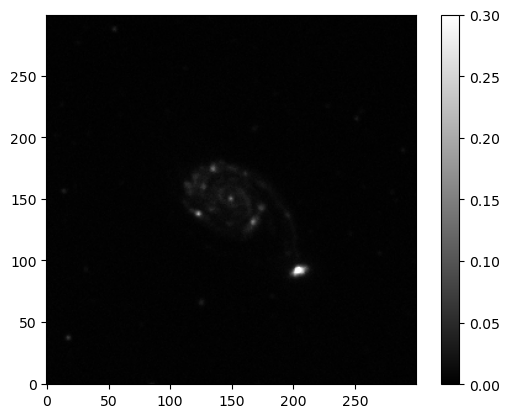

In [7]:
plt.imshow(data_galexuv, cmap='gray', origin='lower',vmin=0,vmax=0.3)
plt.colorbar()

In [8]:
# import optical image 
directory="/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/"
hdul_optical = fits.open(directory+"ngc7753-optical.fits")
header_optical = hdul_optical[0].header
data_optical = hdul_optical[0].data

In [9]:
# import integrated intensity HI map
cube='S2349+2904_HIcube2_clean_smooth_image_5_cube_kms.fits'
mask='S2349+2904_HIcube2_clean_smooth_image_5_mask_kms.fits'
data_intensity=fits.getdata(directory+cube)
data_mask=fits.getdata(directory+mask)
header_intensity=fits.getheader(directory+cube)
# apply the mask 
# apply the mask
masked_data=np.where(data_mask,data_intensity,0)

In [10]:
# create integrated intensity map 
mom0_dat = np.nansum(masked_data,axis=0)*abs(header_intensity['CDELT3'])/1000

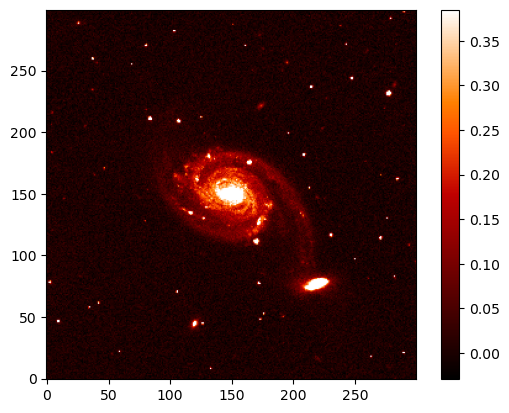

In [11]:
vmin, vmax = np.percentile(data_optical, [1, 99.5])
plt.imshow(data_optical, cmap='gist_heat', vmin=vmin, vmax=vmax,origin='lower')
plt.colorbar()
plt.show()

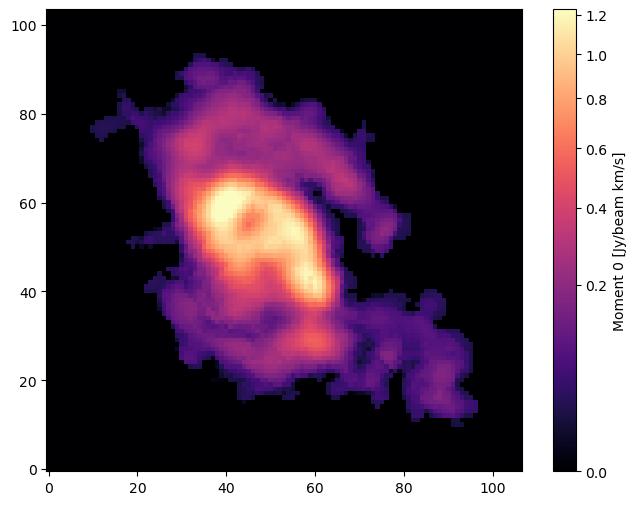

In [12]:
plt.figure(figsize=(8,6))
plt.imshow(mom0_dat,origin='lower',cmap='magma',norm=simple_norm(mom0_dat, 'sqrt', percent=99.5))
plt.colorbar(label='Moment 0 [Jy/beam km/s]')
plt.show()

In [13]:
# Build WCS objects
wcs_opt = WCS(header_optical)
wcs_uv  = WCS(header_galexuv)

# Reproject GALEX onto the optical frame/shape
uv_reproj, footprint = reproject_interp((data_galexuv, wcs_uv), wcs_opt, shape_out=data_optical.shape)
uv_reproj[footprint <= 0] = np.nan  # mask out areas without coverage
# Nice stretches for display
norm_opt = ImageNormalize(data_optical, interval=ZScaleInterval(), stretch=AsinhStretch())
norm_uv  = ImageNormalize(uv_reproj,    interval=ZScaleInterval(), stretch=AsinhStretch())


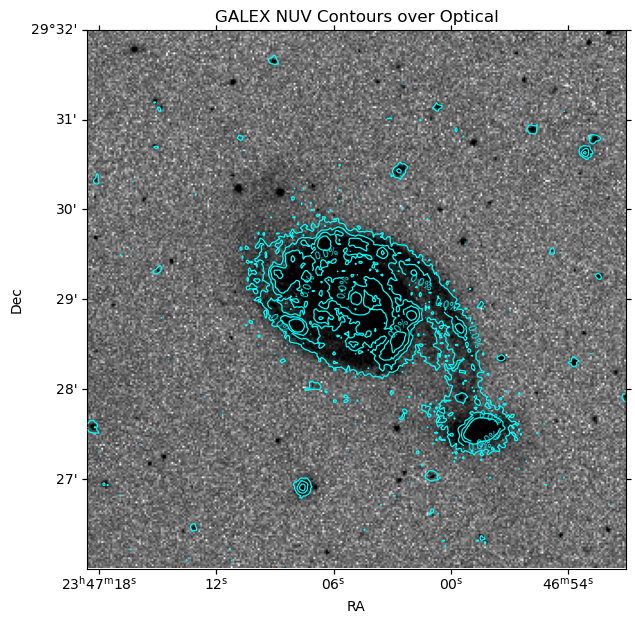

In [14]:
levels = np.nanpercentile(uv_reproj, [90, 95, 98, 99.5])

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_opt)
ax.imshow(data_optical, origin='lower', cmap='gray_r', norm=norm_opt)
cs = ax.contour(uv_reproj, levels=levels, colors='cyan', linewidths=0.9)
ax.clabel(cs, fmt='%.1f%%', inline=True, fontsize=7)
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
ax.set_title('GALEX NUV Contours over Optical')
plt.show()

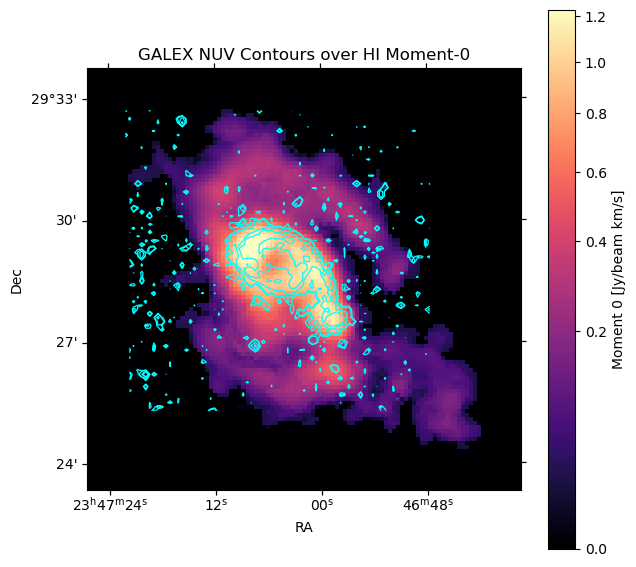

In [110]:
# ...existing code...
# Overlay: GALEX NUV contours on HI moment-0 (mom0_dat) background

# 2D WCS for HI moment-0
wcs_hi2d = WCS(header_intensity).celestial
wcs_uv   = WCS(header_galexuv)

# Reproject GALEX onto the HI frame/shape
uv_on_hi, uv_foot = reproject_interp((data_galexuv, wcs_uv), wcs_hi2d, shape_out=mom0_dat.shape)
uv_on_hi[uv_foot <= 0] = np.nan

# Background stretch for HI
hi_norm = simple_norm(mom0_dat, 'sqrt', percent=99.5)

# Contour levels for GALEX from finite positives
uv_vals = uv_on_hi[np.isfinite(uv_on_hi) & (uv_on_hi > 0)]
if uv_vals.size >= 10:
    uv_levels = np.percentile(uv_vals, [85, 90, 95, 98])
else:
    uv_levels = np.linspace(np.nanmin(uv_on_hi), np.nanmax(uv_on_hi), 4)[1:]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_hi2d)
im = ax.imshow(mom0_dat, origin='lower', cmap='magma', norm=hi_norm)
cs = ax.contour(uv_on_hi, levels=uv_levels, colors='cyan', linewidths=0.9)
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
ax.set_title('GALEX NUV Contours over HI Moment-0')
cb = plt.colorbar(im, ax=ax, label='Moment 0 [Jy/beam km/s]')
plt.show()
# ...existing code...

## Infraded 2MASS-J 

In [5]:
hdul_2massj=fits.open("IF-2mass-J.fits")
header_2massj=hdul_2massj[0].header
data_2massj=hdul_2massj[0].data 

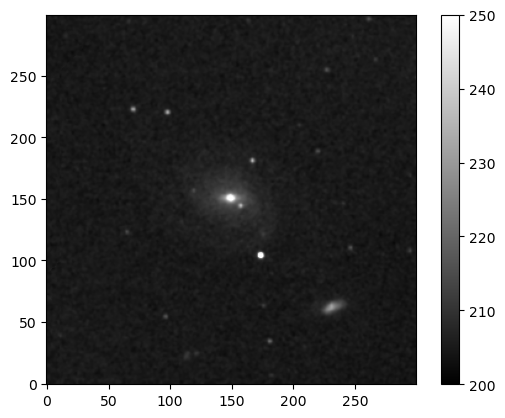

In [112]:
plt.imshow(data_2massj, cmap='gray', origin='lower',vmin=200,vmax=250)
plt.colorbar()

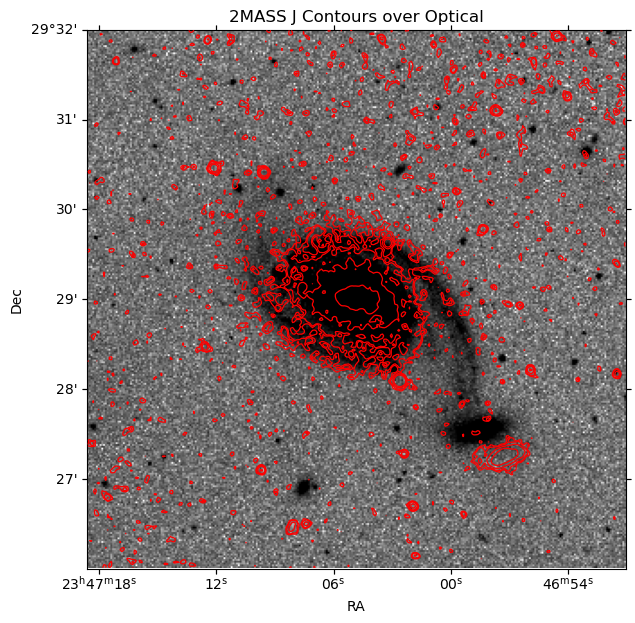

In [113]:
# overleay with the optical image
levels_j = np.nanpercentile(data_2massj, [90, 95, 98, 99.5])
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_opt)
ax.imshow(data_optical, origin='lower', cmap='gray_r', norm=norm_opt)
cs = ax.contour(data_2massj, levels=levels_j, colors='red', linewidths=0.9)
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
ax.set_title('2MASS J Contours over Optical')
plt.show()

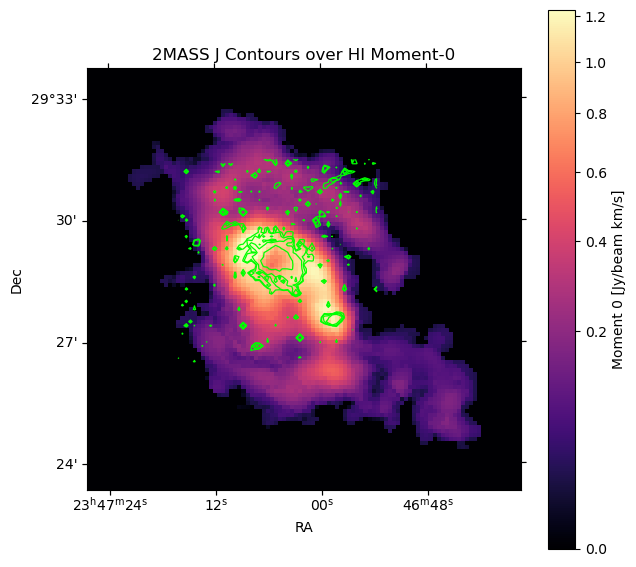

In [114]:
# ...existing code...
# Overlay: 2MASS J contours on HI moment-0 (mom0_dat) background

# 2D WCS for HI and WCS for 2MASS J
wcs_hi2d  = WCS(header_intensity).celestial
wcs_2mass = WCS(header_2massj)

# Ensure 2MASS data is 2D and reproject onto HI frame
j2d = np.squeeze(data_2massj)
j_on_hi, j_foot = reproject_interp((j2d, wcs_2mass), wcs_hi2d, shape_out=mom0_dat.shape)
j_on_hi[j_foot <= 0] = np.nan

# Background stretch for HI
hi_norm = simple_norm(mom0_dat, 'sqrt', percent=99.5)

# Contour levels from finite, positive 2MASS pixels
j_vals = j_on_hi[np.isfinite(j_on_hi) & (j_on_hi > 0)]
if j_vals.size >= 10:
    j_levels = np.percentile(j_vals, [85, 90, 95, 98])
else:
    j_levels = np.linspace(np.nanmin(j_on_hi), np.nanmax(j_on_hi), 4)[1:]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_hi2d)
im = ax.imshow(mom0_dat, origin='lower', cmap='magma', norm=hi_norm)
cs = ax.contour(j_on_hi, levels=j_levels, colors='lime', linewidths=0.9)
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
ax.set_title('2MASS J Contours over HI Moment-0')
plt.colorbar(im, ax=ax, label='Moment 0 [Jy/beam km/s]')
plt.show()
# ...existing code...

## Infrared WISE 22

In [4]:
hdul_wise22=fits.open("Wise22-IF.fits")
header_wise22=hdul_wise22[0].header
data_wise22=hdul_wise22[0].data 

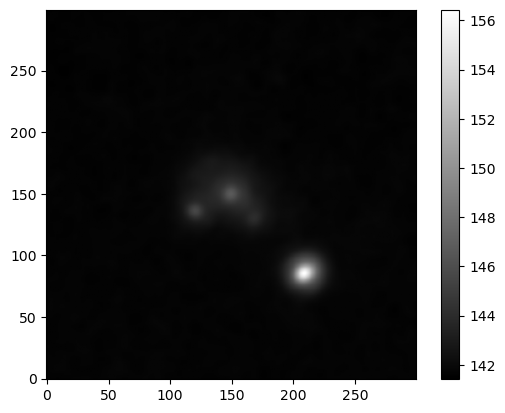

In [116]:
plt.imshow(data_wise22, cmap='gray', origin='lower')
plt.colorbar()

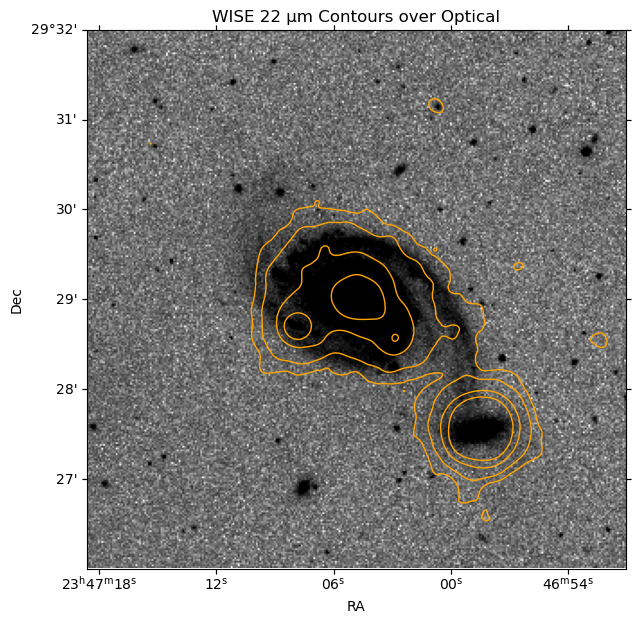

In [117]:
# Overlay WISE 22 µm contours on the optical image

# Build WCS for WISE 22 and reproject onto optical frame
wcs_wise22 = WCS(header_wise22)
wise2d = np.squeeze(data_wise22)  # ensure 2D
wise_reproj, wise_foot = reproject_interp((wise2d, wcs_wise22), wcs_opt, shape_out=data_optical.shape)
wise_reproj[wise_foot <= 0] = np.nan

# Choose contour levels from finite, positive pixels
vals = wise_reproj[np.isfinite(wise_reproj) & (wise_reproj > 0)]
if vals.size >= 10:
    levels_w = np.percentile(vals, [85, 90, 95, 98])
else:
    levels_w = np.linspace(np.nanmin(wise_reproj), np.nanmax(wise_reproj), 4)[1:]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_opt)
ax.imshow(data_optical, origin='lower', cmap='gray_r', norm=norm_opt)
cs = ax.contour(wise_reproj, levels=levels_w, colors='orange', linewidths=1.0)
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
ax.set_title('WISE 22 µm Contours over Optical')
plt.show()

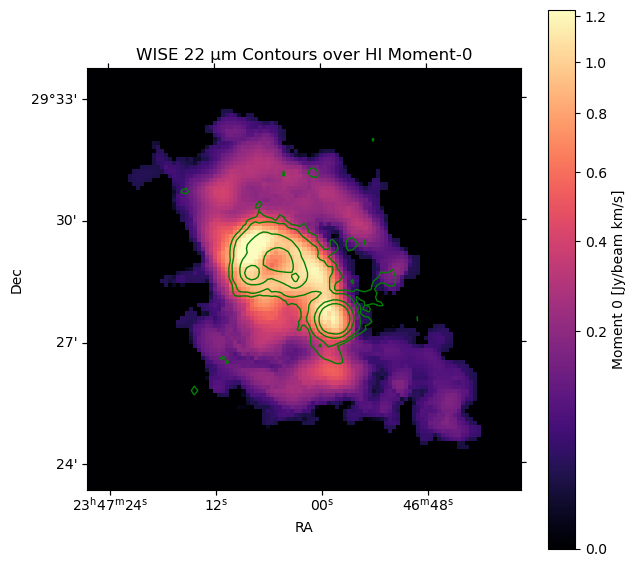

In [118]:
# ...existing code...
# Overlay: WISE 22 µm contours on HI moment-0 (mom0_dat) background

# 2D WCS for HI and WCS for WISE 22
wcs_hi2d   = WCS(header_intensity).celestial
wcs_wise22 = WCS(header_wise22)

# Ensure WISE data is 2D and reproject onto HI frame
wise2d = np.squeeze(data_wise22)
wise_on_hi, wise_foot = reproject_interp((wise2d, wcs_wise22), wcs_hi2d, shape_out=mom0_dat.shape)
wise_on_hi[wise_foot <= 0] = np.nan

# Background stretch for HI
hi_norm = simple_norm(mom0_dat, 'sqrt', percent=99.5)

# Contour levels from finite, positive WISE pixels
vals = wise_on_hi[np.isfinite(wise_on_hi) & (wise_on_hi > 0)]
if vals.size >= 10:
    levels_w = np.percentile(vals, [85, 90, 95, 98])
else:
    levels_w = np.linspace(np.nanmin(wise_on_hi), np.nanmax(wise_on_hi), 4)[1:]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_hi2d)
im = ax.imshow(mom0_dat, origin='lower', cmap='magma', norm=hi_norm)
cs = ax.contour(wise_on_hi, levels=levels_w, colors='green', linewidths=1.0)
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
ax.set_title('WISE 22 µm Contours over HI Moment-0')
plt.colorbar(im, ax=ax, label='Moment 0 [Jy/beam km/s]')
plt.show()
# ...existing code...

# STAR FORMATION RATES

In [25]:
import pandas as pd

In [29]:
data_vizier=pd.read_csv('vizierdata.tsv', delimiter='\t',comment='#')

In [30]:
data_vizier.head()

,Name,Np,RAJ2000,DEJ2000,Gal,NUVFlux,e_NUVFlux,FUVFlux,e_FUVFlux,3.6Flux,...,e_Ha+Cont,Ha,e_Ha,HFlux,e_HFlux,JFlux,e_JFlux,KsFlux,e_KsFlux,SED
0,,,deg,deg,,mJy,mJy,mJy,mJy,mJy,...,mJy,mW/m2,mW/m2,mJy,mJy,mJy,mJy,mJy,mJy,NaN
1,---------------------------,---,-----------,--------------,---------,--------,-------,----------,----------,---------,...,-------,-----------,-------,--------,------,--------,------,--------,------,---
2,Arp104_1_sbt_disk_1_0,1,203.0558000,+62.7644310000,NGC5218,,,,,0.1070,...,,4.2000e-16,,0.140,,0.200,0.020,0.160,0.020,SED
3,Arp104_10_sbt_disk_1_0,1,203.0180600,+62.7727770000,NGC5218,,,,,0.0170,...,,3.1000e-16,,0.082,,0.077,0.009,0.072,,SED
4,Arp104_2_sbt_disk_1_0,1,203.0623900,+62.7670870000,NGC5218,,,,,0.0310,...,0.0200,4.0000e-16,1e-16,0.130,,0.078,,0.093,,SED


In [31]:
data_vizier.describe()

,Name,Np,RAJ2000,DEJ2000,Gal,NUVFlux,e_NUVFlux,FUVFlux,e_FUVFlux,3.6Flux,...,e_Ha+Cont,Ha,e_Ha,HFlux,e_HFlux,JFlux,e_JFlux,KsFlux,e_KsFlux,SED
count,1722,1722,1722,1722,1722,1722,1722,1722,1722,1722,...,1722,1722,1722,1722,1722,1722,1722,1722,1722,1721
unique,1722,4,1612,1623,95,847,27,775,27,1282,...,27,564,23,707,22,778,24,662,22,2
top,,1,356.7692000,-02.8226767000,,,,,,,...,,,,0.170,,0.120,,0.200,,SED
freq,1,1528,3,2,693,159,481,331,595,22,...,1045,857,1045,40,505,46,445,38,561,1720


In [40]:
# Ensure distance from earlier cell is available; if not, set a fallback
try:
    DIST_MPC
except NameError:
    z = 0.017281
    H0 = 70.0
    c_km_s = 299792.458
    D_L_Mpc = (c_km_s * z / H0) * (1 + z)
    DIST_MPC = D_L_Mpc
    print(f"[Info] Using fallback luminosity distance DIST_MPC={DIST_MPC:.3f} Mpc")

D_cm = (DIST_MPC * u.Mpc).to(u.cm).value
four_pi_D2 = 4.0 * np.pi * D_cm**2

In [ ]:
# Compute SFRs from Vizier table fluxes (with correct units)



# Load the Vizier table (already loaded above as data_vizier); reload safely if missing
try:
    data_vizier
except NameError:
    data_vizier = pd.read_csv('vizierdata.tsv', delimiter='\t', comment='#')

cols = {c.lower(): c for c in data_vizier.columns}

def get_col(name_candidates):
    for name in name_candidates:
        key = name.lower()
        if key in cols:
            return cols[key]
    return None

col_nuv = get_col(["NUVFlux","nuvflux","NUV_flux"]) 
col_fuv = get_col(["FUVFlux","fuvflux","FUV_flux"]) 
col_hflux = get_col(["HFlux","hflux","Halpha_flux","HaFlux"]) 
col_ha = get_col(["Ha"])  # mW/m2

# Extract arrays (may be missing) and coerce to numeric
fnu_nuv_mjy = pd.to_numeric(data_vizier[col_nuv], errors='coerce').to_numpy() if col_nuv else None
fnu_fuv_mjy = pd.to_numeric(data_vizier[col_fuv], errors='coerce').to_numpy() if col_fuv else None
fnu_h_mjy = pd.to_numeric(data_vizier[col_hflux], errors='coerce').to_numpy() if col_hflux else None
F_Ha_mwm2 = pd.to_numeric(data_vizier[col_ha], errors='coerce').to_numpy() if col_ha else None

# Convert mJy to Jy
fnu_nuv_jy = fnu_nuv_mjy / 1000.0 if fnu_nuv_mjy is not None else None
fnu_fuv_jy = fnu_fuv_mjy / 1000.0 if fnu_fuv_mjy is not None else None
fnu_h_jy = fnu_h_mjy / 1000.0 if fnu_h_mjy is not None else None

# Convert Ha from mW/m2 to erg/s/cm^2: 1 mW/m2 = 1e-3 W/m2 = 1e-3*1e7 erg/s/cm^2 = 1e4 erg/s/cm^2
F_Ha_erg = F_Ha_mwm2 * 1e4 if F_Ha_mwm2 is not None else None

# Unit assumptions: UV fluxes in Jy (fnu), Hα flux in erg/s/cm^2
jy_to_cgs = (u.Jy).to(u.erg/(u.s*u.cm**2*u.Hz))

def fnu_jy_to_Lnu(fnu_jy):
    fnu_cgs = fnu_jy * jy_to_cgs
    return four_pi_D2 * fnu_cgs

def FHa_to_LHa(FHa_erg):
    return four_pi_D2 * FHa_erg

def sfr_uv(Lnu):
    return 1.4e-28 * Lnu

def sfr_ha(Lha, imf="kroupa"):
    coeff = 5.5e-42 if imf.lower()=="kroupa" else 7.9e-42
    return coeff * Lha

results = pd.DataFrame()
if "Name" in data_vizier.columns:
    results["Name"] = data_vizier["Name"]
elif "name" in data_vizier.columns:
    results["Name"] = data_vizier["name"]
else:
    results["Name"] = np.arange(len(data_vizier))

if fnu_nuv_jy is not None:
    Lnu_nuv = fnu_jy_to_Lnu(fnu_nuv_jy)
    results["SFR_NUV_Msun_per_yr"] = sfr_uv(Lnu_nuv)
else:
    results["SFR_NUV_Msun_per_yr"] = np.nan

if fnu_fuv_jy is not None:
    Lnu_fuv = fnu_jy_to_Lnu(fnu_fuv_jy)
    results["SFR_FUV_Msun_per_yr"] = sfr_uv(Lnu_fuv)
else:
    results["SFR_FUV_Msun_per_yr"] = np.nan

if F_Ha_erg is not None:
    Lha = FHa_to_LHa(F_Ha_erg)
    results["SFR_Halpha_Msun_per_yr"] = sfr_ha(Lha, imf="kroupa")
else:
    results["SFR_Halpha_Msun_per_yr"] = np.nan

n_sources = len(results)
n_nuv = np.isfinite(results["SFR_NUV_Msun_per_yr"]).sum()
n_fuv = np.isfinite(results["SFR_FUV_Msun_per_yr"]).sum()
n_ha  = np.isfinite(results["SFR_Halpha_Msun_per_yr"]).sum()
print(f"Computed SFRs for {n_sources} sources: NUV={n_nuv}, FUV={n_fuv}, Hα={n_ha}")

display(results.head(10))

results.to_csv("catalog_sfrs.csv", index=False)
print("Saved SFR table to catalog_sfrs.csv")

Computed SFRs for 1722 sources: NUV=1561, FUV=1389, Hα=863


,Name,SFR_NUV_Msun_per_yr,SFR_FUV_Msun_per_yr,SFR_Halpha_Msun_per_yr
0,,NaN,NaN,NaN
1,---------------------------,NaN,NaN,NaN
2,Arp104_1_sbt_disk_1_0,NaN,NaN,15.667073
3,Arp104_10_sbt_disk_1_0,NaN,NaN,11.563792
4,Arp104_2_sbt_disk_1_0,NaN,NaN,14.921022
5,Arp104_3_sbt_disk_1_0,NaN,NaN,253.657372
6,Arp104_4_sbt_disk_1_0,NaN,NaN,197.703540
7,Arp104_5_sbt_disk_1_0,NaN,NaN,30.215069
8,Arp104_6_sbt_disk_1_0,NaN,NaN,126.828686
9,Arp104_7_sbt_disk_1_0,NaN,NaN,12.309843


Saved SFR table to catalog_sfrs.csv


In [42]:
data_sfr=pd.read_csv("catalog_sfrs.csv")
print(data_sfr.shape)

(1722, 4)


In [38]:
data_haplha=data_sfr['SFR_Halpha_Msun_per_yr']

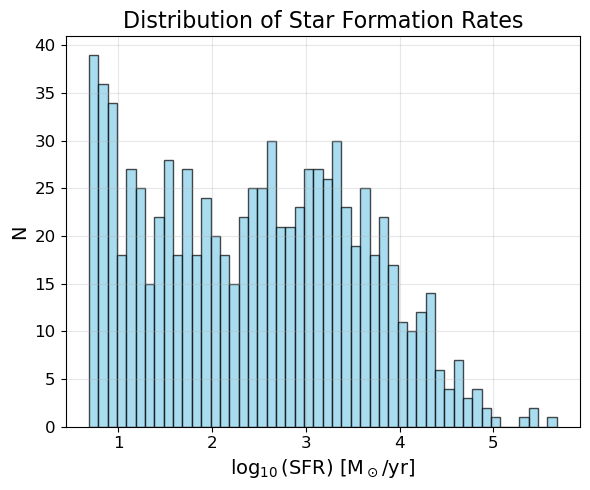

In [41]:
log_sfr=np.log10(data_haplha)

plt.figure(figsize=(6,5)) 
plt.hist(log_sfr, bins=50, edgecolor='black', color='skyblue', alpha=0.7)

plt.xlabel(r'$\log_{10}(\mathrm{SFR})$ [M$_\odot$/yr]', fontsize=14)
plt.ylabel('N', fontsize=14)
plt.title('Distribution of Star Formation Rates', fontsize=16)

plt.grid(alpha=0.3)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## SFR from catalog fluxes (NUV, FUV, Hα)

This section computes integrated Star Formation Rates (SFR) for sources listed in the Vizier table using common calibrations. Assumptions:
- Fluxes (NUVFlux, FUVFlux, HFlux) are total fluxes per source.
- Units: we try to infer from column names/metadata; if unavailable, we assume:
  - UV fluxes are in Jy (fν).
  - Hα fluxes are in erg/s/cm² (integrated line flux).
- Distance uses the earlier `DIST_MPC` derived from redshift (cell near the top).
- Calibrations (approximate, continuous SF, Kroupa/Chabrier-like IMF):
  - UV: SFR_UV [M☉/yr] = 1.4e-28 × Lν [erg/s/Hz] (Kennicutt & Evans 2012).
  - Hα: SFR_Hα [M☉/yr] = 5.5e-42 × L(Hα) [erg/s] (for Kroupa; 7.9e-42 for Salpeter).
- A simple hybrid (if mid-IR 22µm νLν or Hα dust correction is available) can be added later.

Notes: If units differ (e.g., UV counts/s or AB magnitudes), adjust the conversion accordingly.

> **Note on units:**
>
> - NUVFlux, FUVFlux, JFlux, KsFlux, HFlux: **mJy** (milliJansky)
> - Ha: **mW/m²** (milliwatts per square meter)
>
> **Conversions applied in the next cell:**
> - All mJy fluxes are divided by 1000 to get Jy before conversion.
> - Ha in mW/m² is converted to erg/s/cm²: 1 mW/m² = 10⁴ erg/s/cm².